# A4 — Consumo e ruptura

**Pergunta de negócio:** quais itens de consumo vão acabar, e quais têm o estoque mínimo mal definido?

**Método** (módulo `almox.analise.consumo`, views da migração `0010`), só com o histórico:

1. **Demanda diária** (média *d* e variância) nos dias em que havia estoque no início do dia. A demanda observada é **censurada**: num dia sem estoque a saída registrada é zero porque não havia o que entregar, não porque ninguém pediu.
2. **Prazo de entrega real** de cada compra (a data do pedido está na observação da entrada, como numa nota de empenho): média *L* e variância.
3. **Ponto de reposição** = d·L + z·√(L·var_d + d²·var_L), com z = 1,65 (~95% dos ciclos sem falta): a demanda esperada durante o prazo, mais um estoque de segurança que cobre a variação da demanda **e** a do prazo.
4. Comparação com o **mínimo cadastrado**; rupturas = dias consecutivos com saldo zero (técnica *gaps and islands* em SQL).

> Dados 100% fictícios (semente 42), 12 meses até 31/08/2026.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from almox.analise import consumo as a4
from almox.banco import engine
from almox.config import carregar_config_banco

pd.set_option("display.width", 160)
banco = engine(carregar_config_banco())
diario = a4.ler_diario(banco)
prazos = a4.ler_prazos(banco)
resultado = a4.diagnostico(diario, prazos)
resultado.diagnostico.value_counts()

diagnostico
ADEQUADO            17
EXCESSO              3
MINIMO_ABAIXO        3
FORNECEDOR_LENTO     1
Name: count, dtype: int64

## 1. O mínimo cadastrado contra o ponto de reposição calculado

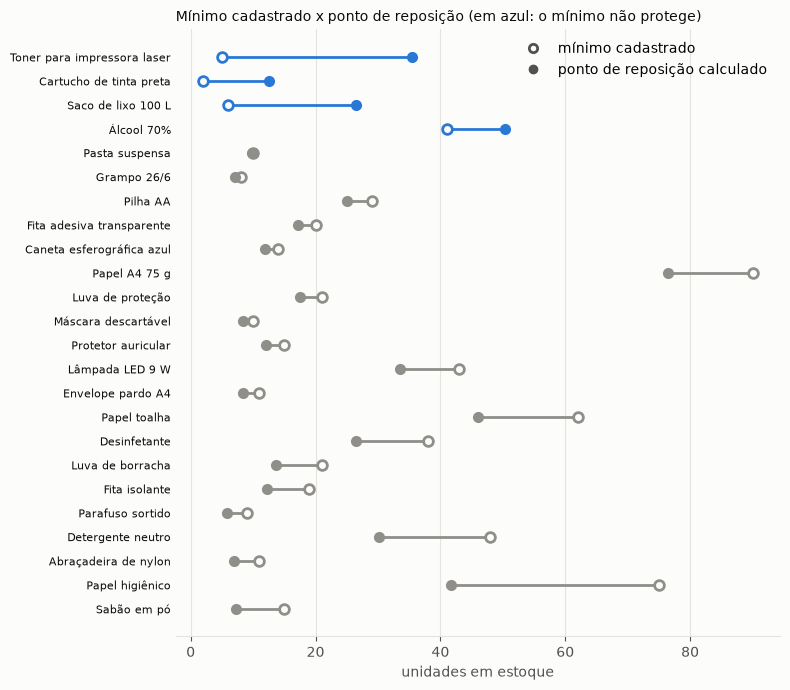

In [2]:
COR = {
    "serie": "#2a78d6",
    "contexto": "#8f8e89",
    "fundo": "#fcfcfb",
    "texto": "#0b0b0b",
    "texto2": "#52514e",
    "grade": "#e4e3df",
}
plt.rcParams.update(
    {
        "figure.facecolor": COR["fundo"],
        "axes.facecolor": COR["fundo"],
        "axes.edgecolor": COR["grade"],
        "axes.labelcolor": COR["texto2"],
        "xtick.color": COR["texto2"],
        "ytick.color": COR["texto"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "font.size": 10,
    }
)

base = resultado.sort_values("razao_minimo", ascending=False)
problema = base.diagnostico.isin(["MINIMO_ABAIXO", "FORNECEDOR_LENTO"])
_fig, ax = plt.subplots(figsize=(8, 7))
for i, (linha, ruim) in enumerate(zip(base.itertuples(), problema, strict=True)):
    cor = COR["serie"] if ruim else COR["contexto"]
    ax.hlines(i, linha.minimo, linha.ponto_de_reposicao, color=cor, linewidth=2)
    ax.plot(linha.minimo, i, "o", mfc=COR["fundo"], mec=cor, mew=2, markersize=7)
    ax.plot(linha.ponto_de_reposicao, i, "o", color=cor, markersize=7)
ax.set_yticks(range(len(base)), base.nome, fontsize=8)
ax.plot([], [], "o", mfc=COR["fundo"], mec=COR["texto2"], mew=2, label="mínimo cadastrado")
ax.plot([], [], "o", color=COR["texto2"], label="ponto de reposição calculado")
ax.legend(loc="upper right", frameon=False)
ax.set_xlabel("unidades em estoque")
ax.set_title(
    "Mínimo cadastrado x ponto de reposição (em azul: o mínimo não protege)",
    loc="left",
    color=COR["texto"],
    fontsize=10,
)
ax.xaxis.grid(True, color=COR["grade"], linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

In [3]:
colunas = [
    "nome",
    "d",
    "d_ingenua",
    "prazo",
    "ponto_de_reposicao",
    "minimo",
    "razao_minimo",
    "dias_zerado",
    "fracao_dias_acima_do_maximo",
    "diagnostico",
]
resultado[resultado.diagnostico != "ADEQUADO"][colunas].round(2)

,nome,d,d_ingenua,prazo,ponto_de_reposicao,minimo,razao_minimo,dias_zerado,fracao_dias_acima_do_maximo,diagnostico
codigo,,,,,,,,,,
EXP-0003,Grampo 26/6,0.19,0.19,14.81,7.08,8,1.13,0,1.0,EXCESSO
EXP-0005,Envelope pardo A4,0.23,0.24,14.81,8.43,11,1.30,0,1.0,EXCESSO
INF-0101,Toner para impressora laser,1.44,1.29,13.50,35.49,5,0.14,56,0.0,MINIMO_ABAIXO
INF-0102,Cartucho de tinta preta,0.39,0.31,15.67,12.55,2,0.16,74,0.0,MINIMO_ABAIXO
LIM-0003,Saco de lixo 100 L,1.01,0.90,13.20,26.55,6,0.23,43,0.0,MINIMO_ABAIXO
LIM-0006,Álcool 70%,0.85,0.82,37.67,50.30,41,0.82,15,0.0,FORNECEDOR_LENTO
LIM-0008,Sabão em pó,0.19,0.19,14.81,7.20,15,2.08,0,1.0,EXCESSO


## 2. Como é uma ruptura recorrente: o saldo do toner

A cada compra o saldo sobe; como o mínimo (5) está muito abaixo da demanda durante o prazo de entrega, o pedido sai tarde e o estoque zera antes de a compra chegar.

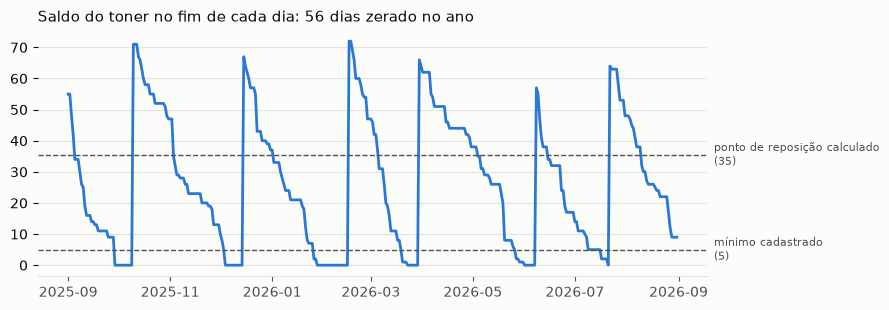

,codigo,nome,inicio,fim,dias
0,INF-0101,Toner para impressora laser,2025-09-29,2025-10-09,11
1,INF-0101,Toner para impressora laser,2025-12-04,2025-12-14,11
2,INF-0101,Toner para impressora laser,2026-01-28,2026-02-15,19
3,INF-0101,Toner para impressora laser,2026-03-23,2026-03-29,7
4,INF-0101,Toner para impressora laser,2026-06-01,2026-06-07,7
5,INF-0101,Toner para impressora laser,2026-07-21,2026-07-21,1


In [4]:
toner = diario[diario.codigo == "INF-0101"]
linha = resultado.loc["INF-0101"]
_fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(pd.to_datetime(toner.dia), toner.saldo_fim_do_dia, color=COR["serie"], linewidth=2)
for valor, rotulo in [
    (linha.minimo, f"mínimo cadastrado ({linha.minimo:.0f})"),
    (linha.ponto_de_reposicao, f"ponto de reposição calculado ({linha.ponto_de_reposicao:.0f})"),
]:
    ax.axhline(valor, color=COR["texto2"], linewidth=1, linestyle="--")
    # rótulo na margem direita, fora da área dos dados
    ax.text(
        1.01,
        valor,
        rotulo.replace(" (", "\n("),
        transform=ax.get_yaxis_transform(),
        va="center",
        color=COR["texto2"],
        fontsize=8,
    )
ax.set_title(
    f"Saldo do toner no fim de cada dia: {linha.dias_zerado:.0f} dias zerado no ano",
    loc="left",
    color=COR["texto"],
    fontsize=11,
)
ax.yaxis.grid(True, color=COR["grade"], linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
pd.read_sql("SELECT * FROM analise.vw_ruptura WHERE codigo = 'INF-0101' ORDER BY inicio", banco)

## 3. Prazo de entrega: o fornecedor lento

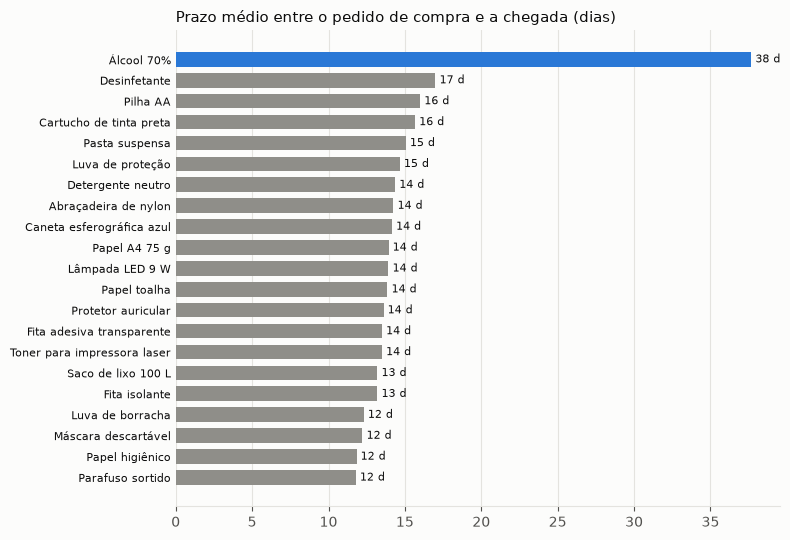

In [5]:
prazo = prazos.groupby("nome").prazo_dias.mean().sort_values()
destaque = prazo.idxmax()
_fig, ax = plt.subplots(figsize=(8, 5.5))
cores = [COR["serie"] if n == destaque else COR["contexto"] for n in prazo.index]
b = ax.barh(prazo.index, prazo.values, height=0.7, color=cores)
ax.bar_label(
    b, labels=[f"{v:.0f} d" for v in prazo.values], padding=3, color=COR["texto"], fontsize=8
)
ax.set_title(
    "Prazo médio entre o pedido de compra e a chegada (dias)",
    loc="left",
    color=COR["texto"],
    fontsize=11,
)
ax.xaxis.grid(True, color=COR["grade"], linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0, labelsize=8)
plt.tight_layout()
plt.show()

## 4. Situação na data de referência

In [6]:
status = pd.read_sql("SELECT * FROM analise.vw_status_consumo", banco)
status[status.status.isin(["SEM_ESTOQUE", "CRITICO", "ACIMA_DO_MAXIMO"])][
    ["nome", "quantidade", "estoque_minimo", "estoque_maximo", "status"]
]

,nome,quantidade,estoque_minimo,estoque_maximo,status
1,Caneta esferográfica azul,6,14,24,CRITICO
4,Envelope pardo A4,21,11,17,ACIMA_DO_MAXIMO
13,Álcool 70%,19,41,68,CRITICO
15,Sabão em pó,78,15,24,ACIMA_DO_MAXIMO


## 5. Conferência com o gabarito do gerador

O gerador calibrou cada material de propósito (bem, mal, fornecedor lento, excesso). A análise acima não usou isso; aqui é só a conferência.

In [7]:
import json

from almox.config import RAIZ_PROJETO

verdade = json.loads(
    (RAIZ_PROJETO / "data/gerado/gabarito_padroes.json").read_text(encoding="utf-8")
)["calibracao_consumo"]
pd.crosstab(
    resultado.diagnostico,
    resultado.index.map(verdade),
    rownames=["diagnóstico da análise"],
    colnames=["calibração plantada"],
)

calibração plantada,bom,excesso,fornecedor_lento,mal_calibrado
diagnóstico da análise,,,,
ADEQUADO,17,0,0,0
EXCESSO,0,3,0,0
FORNECEDOR_LENTO,0,0,1,0
MINIMO_ABAIXO,0,0,0,3


A mesma análise, aplicada a quatro outros conjuntos gerados com sementes que as regras nunca viram, acertou os 24 materiais em todos. A margem é folgada: nos bem calibrados o mínimo nunca ficou abaixo de 84% do ponto de reposição, e nos mal calibrados nunca passou de 23%. O limiar de 60% fica no meio.

## Insights

1. **Três mínimos não protegem contra a falta.** O mínimo do toner é 5, e o ponto de reposição calculado é 35 (7 vezes mais). Foram 56 dias sem toner no ano, em 6 episódios de até 19 dias. Cartucho de tinta: 74 dias zerado. Saco de lixo: 43. **Recomendação:** mínimo = ponto de reposição calculado (35, 13 e 27).
2. **O álcool 70% falta por causa do fornecedor, não do mínimo.** O pedido leva em média 38 dias para chegar, contra 13 do prazo típico. Com esse prazo, o ponto de reposição é 50, e o mínimo cadastrado (41) só servia para o prazo normal. **Na data de referência o álcool está crítico** (19 unidades, abaixo de metade do mínimo), com um prazo de entrega de mais de um mês: é o pedido a fazer já. A solução estrutural é trocar ou cobrar o fornecedor, ou subir o mínimo.
3. **A demanda medida sem cuidado engana.** Contando os dias sem estoque, a demanda do cartucho parece 21% menor do que é (0,31 contra 0,39 por dia), e a do toner, 10% menor. Os itens que mais faltam são justamente os mais subestimados. Por isso a análise usa só os dias com estoque.
4. **Excesso em três itens baratos.** Grampo, envelope e sabão em pó ficaram acima do máximo o ano inteiro (compra de mais de um ano de demanda). O valor é pequeno, mas é a mesma falha de processo com sinal trocado: comprar sem olhar o máximo.
5. **O resto está bem calibrado.** Dos 17 itens adequados, 14 não faltaram nenhum dia; os outros 3 faltaram de 2 a 7 dias, incluindo o desinfetante no pico de janeiro.